## 📊 Task 4 – Sentiment Analysis using NLP
### Dataset: Google Play Store App Reviews

This notebook performs sentiment analysis on user reviews to uncover user satisfaction, frustrations, and key feedback patterns. 
It is part of a Data Analytics Internship and aligns with product-focused roles.
### Objective
To identify patterns and trends in user sentiment towards a productivity mobile app using Natural Language Processing (NLP).

In [14]:
#Step 1: Load & Inspect the Data
import pandas as pd

# Load CSV
df = pd.read_csv(r'C:\Users\Soumiya\Desktop\Durga\Career_2025\CodTech_Internship\Task 4 - Sentiment_Analysis\Reviews_Dataset.csv')

# Overview of data
print("Shape of dataset:", df.shape)
print("Columns:", df.columns)
df.head()

Shape of dataset: (12495, 12)
Columns: Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'sortOrder', 'appId'],
      dtype='object')


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo


## Step 2: Data Cleaning
- Drop null values
- Remove duplicates
- Check class balance (positive, neutral, negative)


In [15]:
# Drop empty content
df.dropna(subset=['content'], inplace=True)

# Drop duplicates
df.drop_duplicates(subset=['content'], inplace=True)

# Create sentiment column from score
# 1-2 => Negative, 3 => Neutral, 4-5 => Positive

def convert_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df['Sentiment'] = df['score'].apply(convert_sentiment)

# Check counts
df['Sentiment'].value_counts()

Sentiment
Positive    5131
Negative    4764
Neutral     1912
Name: count, dtype: int64

In [16]:
df[['content', 'score', 'Sentiment']].head()

,content,score,Sentiment
0,I cannot open the app anymore,1,Negative
1,I have been begging for a refund from this app...,1,Negative
2,Very costly for the premium version (approx In...,1,Negative
3,"Used to keep me organized, but all the 2020 UP...",1,Negative
4,Dan Birthday Oct 28,1,Negative


In [17]:
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Define stop words
stop_words = set(stopwords.words('english'))

# Manual text cleaning function
def clean_text_basic(text):
    # Lowercase text
    text = text.lower()
    
    # Tokenize (split on whitespace and punctuation)
    tokens = text.split()
    
    # Remove punctuation and stopwords
    tokens = [t.strip(string.punctuation) for t in tokens if t not in stop_words]
    
    # Lemmatize tokens
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return " ".join(tokens)

# Apply to dataset
df['Clean_Review'] = df['content'].apply(clean_text_basic)
df[['content', 'Clean_Review', 'Sentiment']].head()

,content,Clean_Review,Sentiment
0,I cannot open the app anymore,cannot open app anymore,Negative
1,I have been begging for a refund from this app...,begging refund app month nobody replying,Negative
2,Very costly for the premium version (approx In...,costly premium version approx indian rupee 910...,Negative
3,"Used to keep me organized, but all the 2020 UP...",used keep organized 2020 update made mess thin...,Negative
4,Dan Birthday Oct 28,dan birthday oct 28,Negative


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# Fit and transform the clean reviews
X_tfidf = tfidf_vectorizer.fit_transform(df['Clean_Review'])

# Convert sparse matrix to DataFrame for better readability (optional)
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print(X_tfidf_df.head())

    00  000  00am  00hrm  00pm   01   03   04   05   06  ...  يمكن   چپ  کار  \
0  0.0  0.0   0.0    0.0   0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0  0.0  0.0   
1  0.0  0.0   0.0    0.0   0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0  0.0  0.0   
2  0.0  0.0   0.0    0.0   0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0  0.0  0.0   
3  0.0  0.0   0.0    0.0   0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0  0.0  0.0   
4  0.0  0.0   0.0    0.0   0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0  0.0  0.0   

   کامل   که  گذاری  گوشی   งม  ยเง  แอคเคาท  
0   0.0  0.0    0.0   0.0  0.0  0.0      0.0  
1   0.0  0.0    0.0   0.0  0.0  0.0      0.0  
2   0.0  0.0    0.0   0.0  0.0  0.0      0.0  
3   0.0  0.0    0.0   0.0  0.0  0.0      0.0  
4   0.0  0.0    0.0   0.0  0.0  0.0      0.0  

[5 rows x 5000 columns]


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=3000)

# Fit and transform the cleaned text
X = vectorizer.fit_transform(df['Clean_Review'])

# Define the target
y = df['Sentiment']

In [20]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7011007620660458
Classification Report:
               precision    recall  f1-score   support

    Negative       0.69      0.83      0.76       953
     Neutral       0.26      0.06      0.10       383
    Positive       0.75      0.82      0.78      1026

    accuracy                           0.70      2362
   macro avg       0.57      0.57      0.55      2362
weighted avg       0.65      0.70      0.66      2362



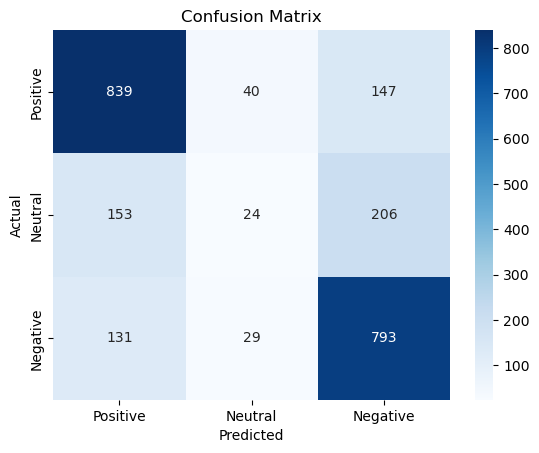

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["Positive", "Neutral", "Negative"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Positive", "Neutral", "Negative"], yticklabels=["Positive", "Neutral", "Negative"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
pip install wordcloud

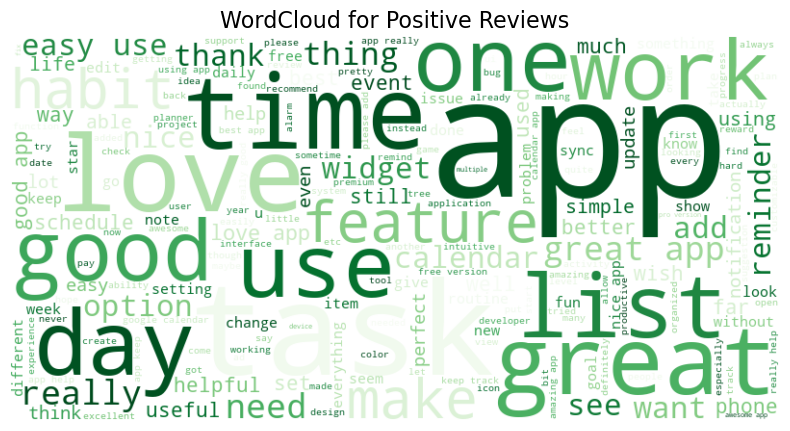

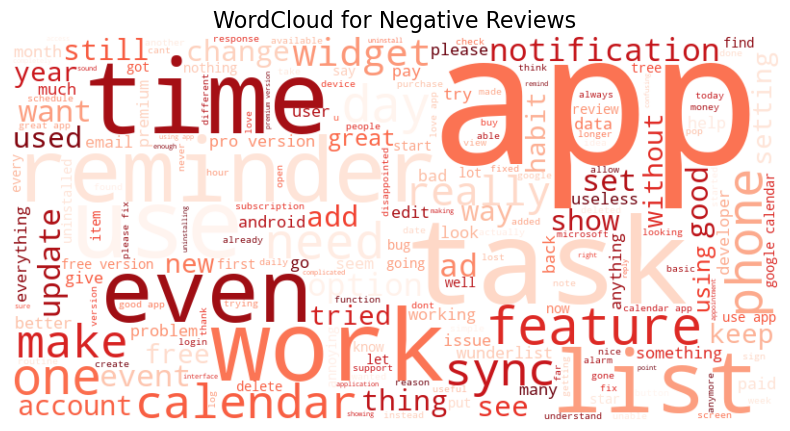

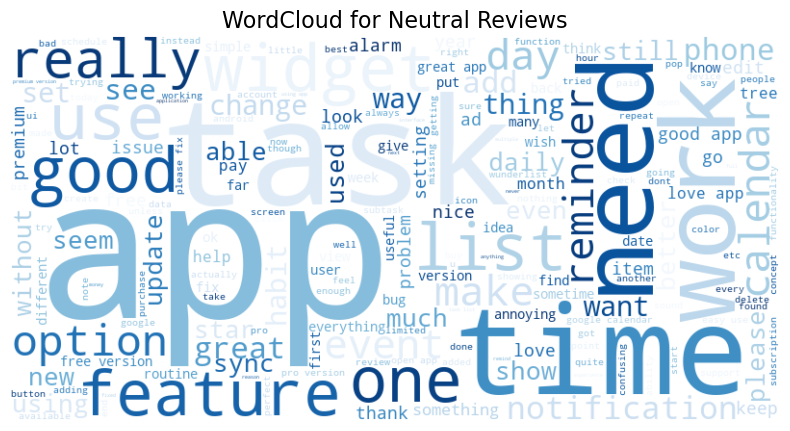

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Function to generate wordcloud
def plot_wordcloud(sentiment_label, color):
    text = " ".join(df[df['Sentiment'] == sentiment_label]['Clean_Review'])
    wc = WordCloud(width=800, height=400, background_color='white', colormap=color).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for {sentiment_label} Reviews", fontsize=16)
    plt.show()

# Generate word clouds
plot_wordcloud("Positive", "Greens")
plot_wordcloud("Negative", "Reds")
plot_wordcloud("Neutral", "Blues")

### Key Insights
1.	Positive reviews dominate (~44%), indicating strong app value.
2.  Top positive drivers: “love”, “easy”, “habit”, “calendar”, “thank”.
3.  Neutral reviews highlight feature expectations like sync, reminder, options.
4.  Negative reviews expose bugs, ads, crashes, and update issues.
5.  Accuracy of basic TF-IDF + Logistic Regression model: ~70%

### Recommendations
1. Reduce Ads / Improve Ad Experience: "ads" was a major negative keyword.
2. Enhance Sync & Update Stability: Many users struggle with app sync and buggy updates.
3. Boost Premium Appeal: Negative mentions around "cost", "premium" — needs clarity or value addition.
4. Use Feedback Loops: Analyze reviews regularly to prioritize product roadmap with real voice-of-customer data.
5. Future: Integrate topic modeling (e.g., LDA) to extract deeper themes from reviews.